# Michael Vazquez<br>Econ 586, Assignment 1<br>Link to code: 

# Imports.

In [134]:
import pandas as pd
import numpy as np
import scipy.stats

import statsmodels.api as sm
from statsmodels.tsa.filters.hp_filter import hpfilter
from statsmodels.tsa.stattools import acf

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import os

from IPython import get_ipython
from IPython.display import Image, display

# Notebook variables.

In [135]:
assignment_1_dir = os.getenv("ECON_586_ASSIGNMENT_1_DIR")
assignment_1_images_dir = os.getenv("ECON_586_ASSIGNMENT_1_IMAGES_DIR")

# Question 1.0 - Download US real per capita GDP from 1947Q1 to 2025Q3.

## US real GDP, series identifier A939RX0Q048SBEA, no edits to data before download:<br>https://fred.stlouisfed.org/series/A939RX0Q048SBEA

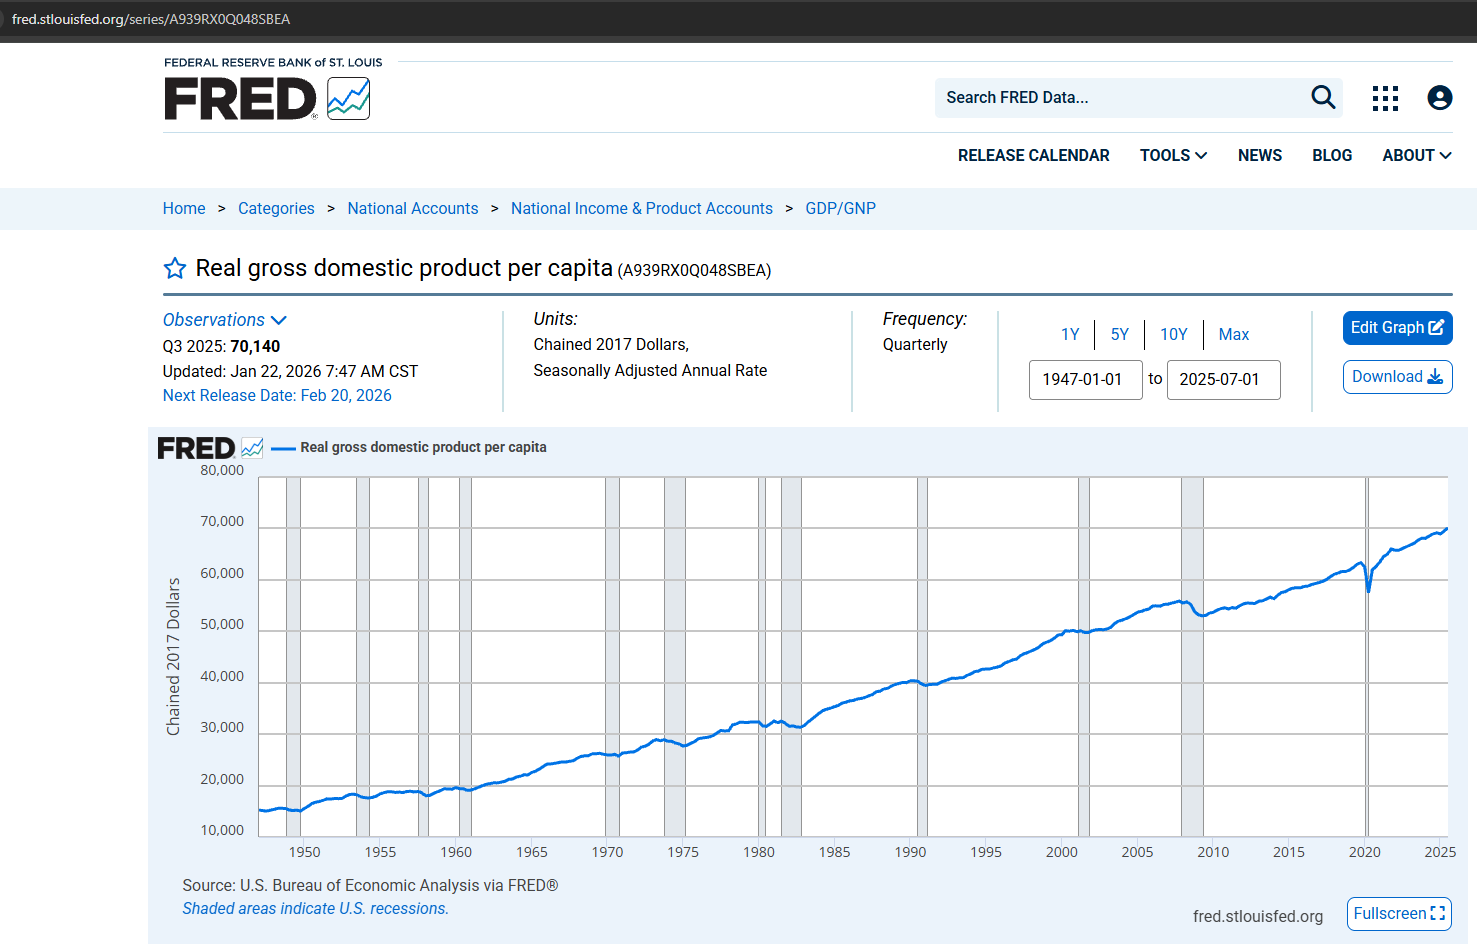

In [136]:
display(Image(rf'{assignment_1_images_dir}\\fred_gdp_quarterly_download.png'))

## Read the downloaded GDP data and assign dtypes.

In [137]:
df_gdp = pd.read_csv(
    rf'{assignment_1_dir}\\fred_real_gdp_A939RX0Q048SBEA.csv'
)
df_gdp['observation_date'] = pd.to_datetime(df_gdp['observation_date'])
df_gdp = df_gdp.rename(columns={'A939RX0Q048SBEA': 'gdp'})
# Time series so set the index as the date column.
df_gdp = df_gdp.set_index('observation_date')
print("GDP file successfully read.")
print(df_gdp.info())

GDP file successfully read.
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 315 entries, 1947-01-01 to 2025-07-01
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   gdp     315 non-null    int64
dtypes: int64(1)
memory usage: 4.9 KB
None


## Question 1.1 - Plot the log of GDP.

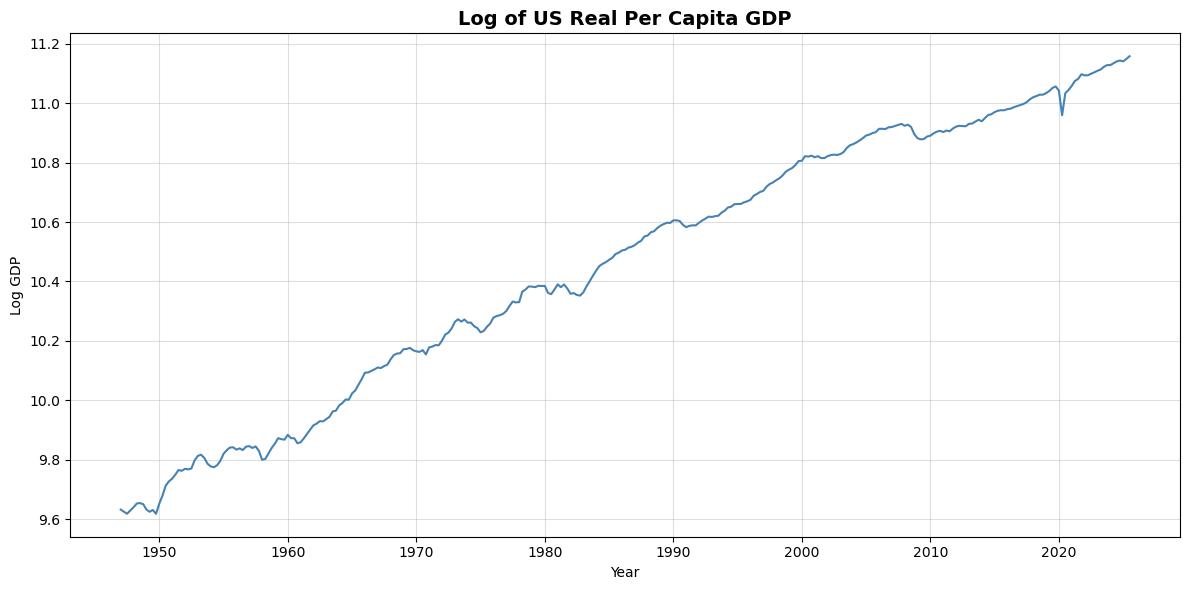

In [138]:
df_gdp = df_gdp.assign(
    log_gdp = np.log(df_gdp['gdp'])
)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df_gdp.index, df_gdp['log_gdp'], linewidth=1.5, color='steelblue')
ax.set_title('Log of US Real Per Capita GDP', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Log GDP')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()



# Question 2.1 - OLS, trends, and cycles.

## Run the OLS model as mentioned in Chapter 1, Section 1.2.

y_hat = 9.6756 + 0.0049 * t
Average annual growth rate per capita of GDP: 1.9725%
R squared: 0.9856
                            OLS Regression Results                            
Dep. Variable:                log_gdp   R-squared:                       0.986
Model:                            OLS   Adj. R-squared:                  0.986
Method:                 Least Squares   F-statistic:                 2.145e+04
Date:                Thu, 12 Feb 2026   Prob (F-statistic):          2.33e-290
Time:                        23:29:09   Log-Likelihood:                 471.46
No. Observations:                 315   AIC:                            -938.9
Df Residuals:                     313   BIC:                            -931.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------

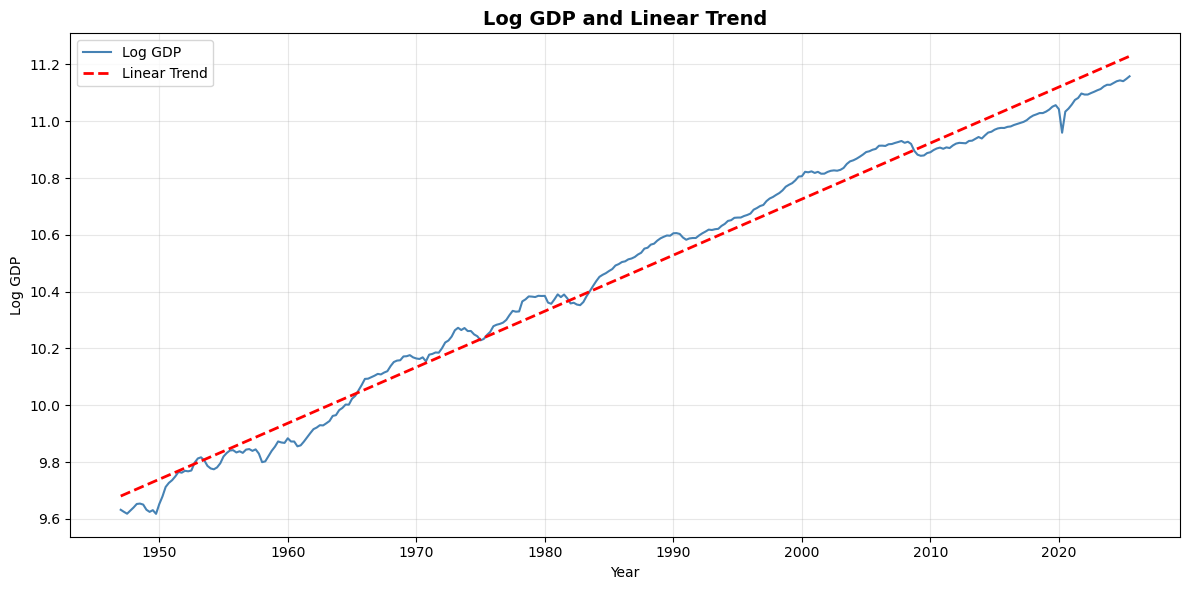

In [139]:

T = df_gdp.shape[0]
time_trend = np.arange(1, T + 1)
y = df_gdp['log_gdp']

# Add the constant.
X = sm.add_constant(time_trend)  # Adds intercept column
model = sm.OLS(y, X)
results = model.fit()

# Extract the coefficients, trend, and cycle from the statsmodels results.
alpha, beta = results.params
linear_trend = results.fittedvalues
linear_cycle = results.resid

# Place the results in the df.
df_gdp = df_gdp.assign(
    linear_trend = linear_trend,
    linear_cycle = linear_cycle
)

# Per the FRED download, the data is quarterly. Thus need to multiply
# by 4 here. Here we intepret beta as the quarterly growth rate.
annual_growth = beta * 4 * 100

print(f"y_hat = {alpha:.4f} + {beta:.4f} * t")
print(f"Average annual growth rate per capita of GDP: {annual_growth:.4f}%")
print(f"R squared: {results.rsquared:.4f}")
print(results.summary())

# Plot the trend over the data.
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(
    df_gdp.index,
    df_gdp['log_gdp'],
    label='Log GDP',
    linewidth=1.5,
    color='steelblue'
)
ax.plot(
    df_gdp.index,
    df_gdp['linear_trend'],
    label='Linear Trend',
    linewidth=2,
    color='red',
    linestyle='--'
)
ax.set_title('Log GDP and Linear Trend', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Log GDP')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Cyclical component, ie residuals.

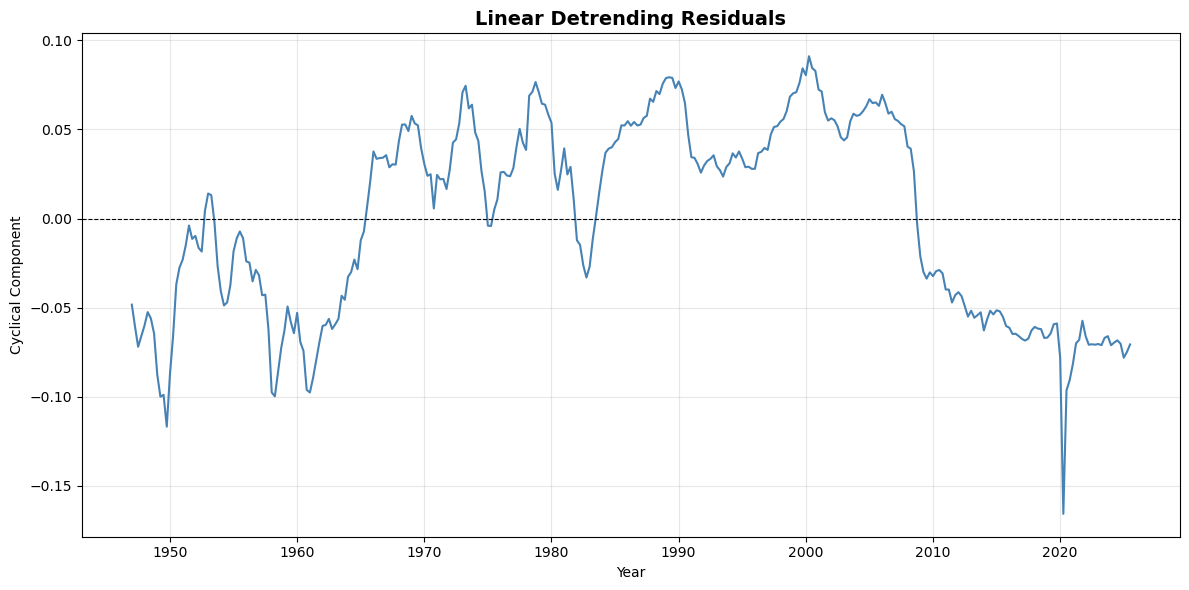

In [140]:

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(
    df_gdp.index,
    df_gdp['linear_cycle'],
    linewidth=1.5,
    color='steelblue'
)
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
ax.set_title('Linear Detrending Residuals', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Cyclical Component')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Standard deviation, first sample autocorrelation, and linear detrending process.

In [141]:

linear_std = df_gdp['linear_cycle'].std()

# Autocorrelation using statsmodels. Formulas on Chapter 1, page 12.
linear_acf = acf(df_gdp['linear_cycle'], nlags=1, fft=False)
 # Get the first autocorrelation.
linear_autocorr = linear_acf[1]

print(f"Cyclical component statistics:")
print(f"Standard deviation: {linear_std:.4f}")
print(f"First sample autocorrelation: {linear_autocorr:.4f}")


Cyclical component statistics:
Standard deviation: 0.0543
First sample autocorrelation: 0.9753


## With the first sample autocorrelation equal to 0.9753, we find that the linear detrending process was not adequate.

# Question 3.1 - Calculate HP filtered series with lambda = 1600.

## Apply the HP filter to the GDP data.

In [142]:
# Apply HP filter using statsmodels.
# lambda = 1600 is appropriate for quarterly data, per page 11 of chapter 1.
hp_cycle, hp_trend = hpfilter(df_gdp['log_gdp'], lamb=1600)

df_gdp = df_gdp.assign(
    hp_trend = hp_trend,
    hp_cycle = hp_cycle
)

## Plot of HP trend and log of GDP.

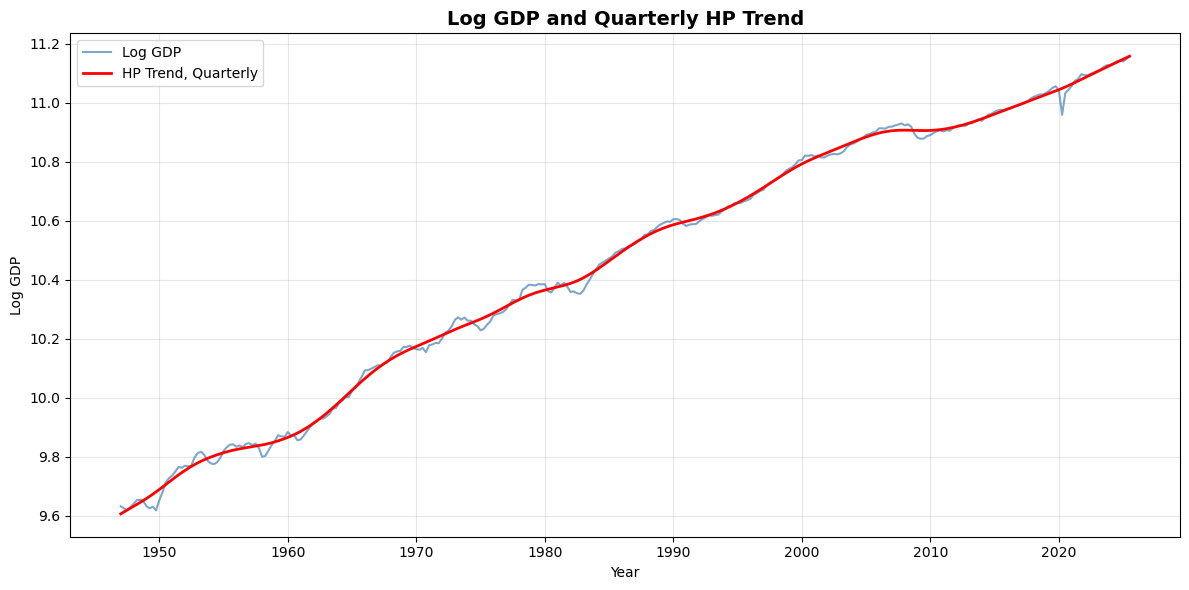

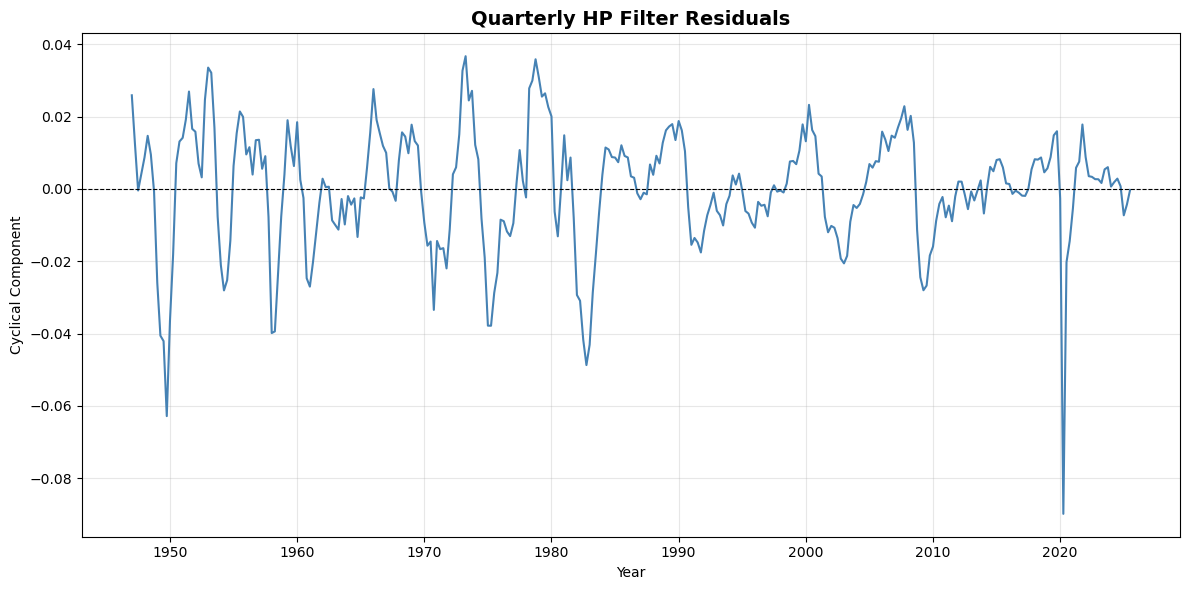

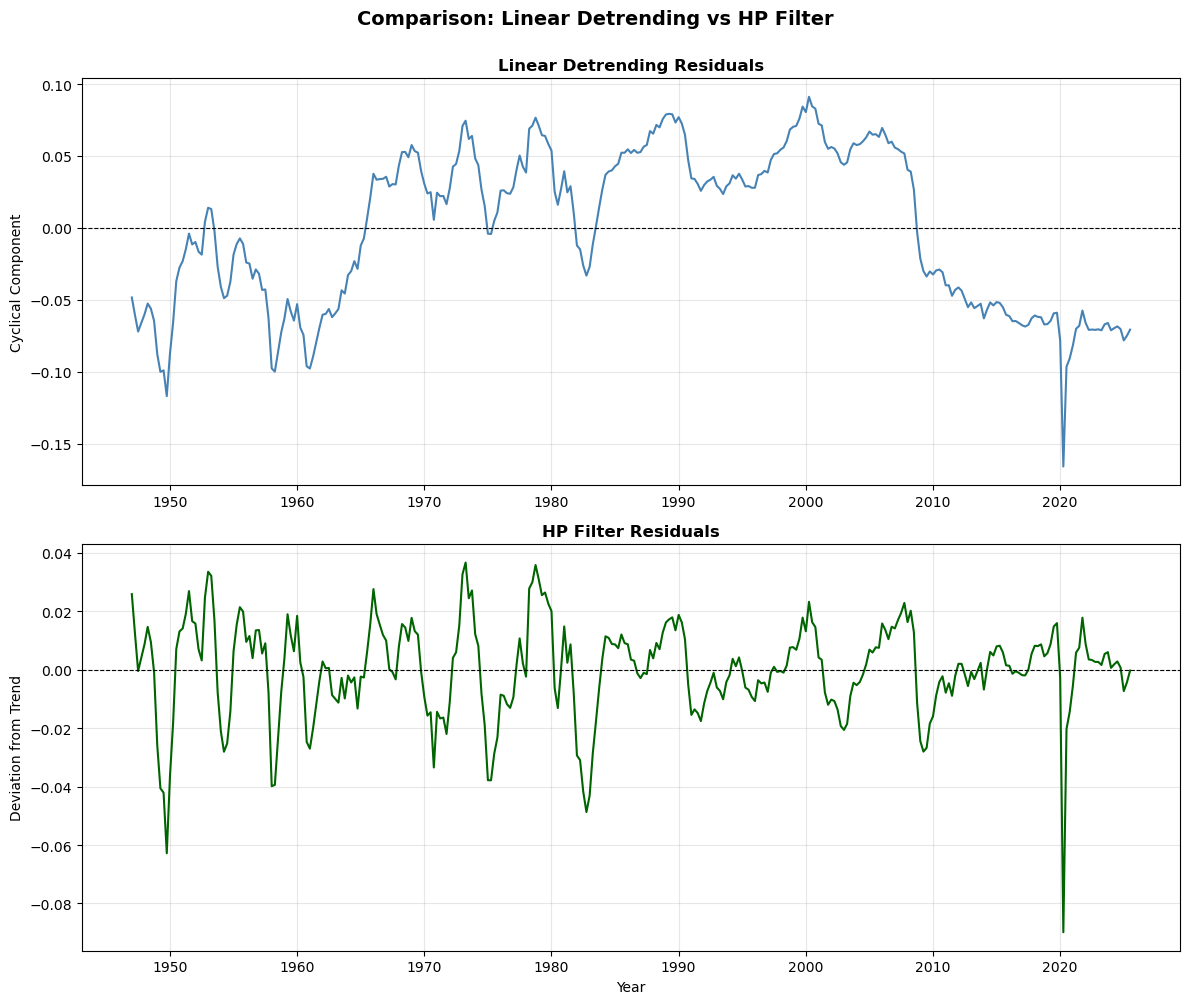

In [143]:

# Plot log of GDP on same plot of HP filtered data..
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(
    df_gdp.index,
    df_gdp['log_gdp'],
    label='Log GDP',
    linewidth=1.5,
    color='steelblue',
    alpha=0.7)
ax.plot(
    df_gdp.index,
    df_gdp['hp_trend'],
    label='HP Trend, Quarterly',
    linewidth=2,
    color='red'
)
ax.set_title('Log GDP and Quarterly HP Trend', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Log GDP')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot HP filtered data.
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df_gdp.index, df_gdp['hp_cycle'], linewidth=1.5, color='steelblue')
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
# Quarterly ie lambda = 1600.
ax.set_title('Quarterly HP Filter Residuals', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Cyclical Component')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Compare the residuals of linear detrending vs HP filter.
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Copy and paste from question 2.
ax1.plot(df_gdp.index, df_gdp['linear_cycle'], linewidth=1.5, color='steelblue')
ax1.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
ax1.set_title('Linear Detrending Residuals', fontsize=12, fontweight='bold')
ax1.set_ylabel('Cyclical Component')
ax1.grid(True, alpha=0.3)

# Plot HP residuals.
ax2.plot(df_gdp.index, df_gdp['hp_cycle'], linewidth=1.5, color='darkgreen')
ax2.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
ax2.set_title('HP Filter Residuals', fontsize=12, fontweight='bold')
ax2.set_xlabel('Year')
ax2.set_ylabel('Deviation from Trend')
ax2.grid(True, alpha=0.3)

fig.suptitle('Comparison: Linear Detrending vs HP Filter', 
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()


## Sample standard deviation and first eight autocorrelations of HP filtered cyclical component.

In [144]:

hp_std = df_gdp['hp_cycle'].std()

# Get first 8 autocorrelations using statsmodels
hp_acf = acf(df_gdp['hp_cycle'], nlags=8, fft=False)
# Exclude the lag.
hp_autocorrs = hp_acf[1:]

print(f"HP filtered cyclical component ctatistics:")
print(f"Standard deviation: {hp_std:.4f}")
print(f"First 8 sample autocorrelations:")
for i, ac in enumerate(hp_autocorrs, 1):
    print(f"Lag {i}: {ac:7.4f}")


HP filtered cyclical component ctatistics:
Standard deviation: 0.0164
First 8 sample autocorrelations:
Lag 1:  0.7848
Lag 2:  0.5479
Lag 3:  0.2977
Lag 4:  0.0810
Lag 5: -0.0787
Lag 6: -0.1815
Lag 7: -0.2348
Lag 8: -0.2535


# Question 4.1 - Obtain and graph the HP filtered cyclical component of each series using lambda = 1600.

## Load the ycih file.

In [145]:
df_ycih = pd.read_csv('ycih.txt', sep=r'\s+', header=None)
# The column names are given in the question 4 instructions.
df_ycih.columns = ['Y', 'C', 'I', 'H']
# Set a quarterly index. 'ycih_readme.txt' tells us that the data is quarterly
# and also tells us the date range of the data.
ycih_periods = pd.date_range(start='1947Q1', periods=df_ycih.shape[0], freq='QS')
df_ycih = df_ycih.set_index(ycih_periods)
print(df_ycih.info())
display(df_ycih.sample(n=10))

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 228 entries, 1947-01-01 to 2003-10-01
Freq: QS-JAN
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Y       228 non-null    float64
 1   C       228 non-null    float64
 2   I       228 non-null    float64
 3   H       228 non-null    float64
dtypes: float64(4)
memory usage: 8.9 KB
None


,Y,C,I,H
1986-04-01,6588.234326,5418.467293,1169.767034,31.917694
1991-01-01,6898.824191,5810.276474,1088.547717,31.070106
1970-07-01,5095.373478,4229.102983,866.270494,30.610718
1989-04-01,6960.556845,5742.062105,1218.494740,32.736866
1984-10-01,6481.512558,5259.970912,1221.541646,31.683168
2003-04-01,9372.208281,7303.923109,2068.285172,31.460291
1958-10-01,3805.117532,3224.796629,580.320904,31.658578
1957-10-01,3659.166973,3123.631043,535.535930,31.015087
1967-01-01,4812.679236,4001.922021,810.757215,32.125206
1971-01-01,5146.038841,4262.589676,883.449165,30.812129


## As mentioned in Chapter 1, take logs of the GDP related columns.

In [146]:
# Don't take the log of H since that is hours, not used in GDP formula, Y = C + I + G + NX.
df_ycih = df_ycih.assign(
    log_Y = np.log(df_ycih['Y']),
    log_C = np.log(df_ycih['C']),
    log_I = np.log(df_ycih['I'])
)

## Apply HP filter.

In [147]:
for col in ['Y', 'C', 'I']:
    cycle, trend = hpfilter(df_ycih[f'log_{col}'], lamb=1600)
    df_ycih[f'{col}_cycle'] = cycle
    df_ycih[f'{col}_trend'] = trend

# Slighly different column name, no 'log' in the column name here.
cycle, trend = hpfilter(df_ycih['H'], lamb=1600)
df_ycih['H_cycle'] = cycle
df_ycih['H_trend'] = trend

## Plot the HP filtered ycih data.

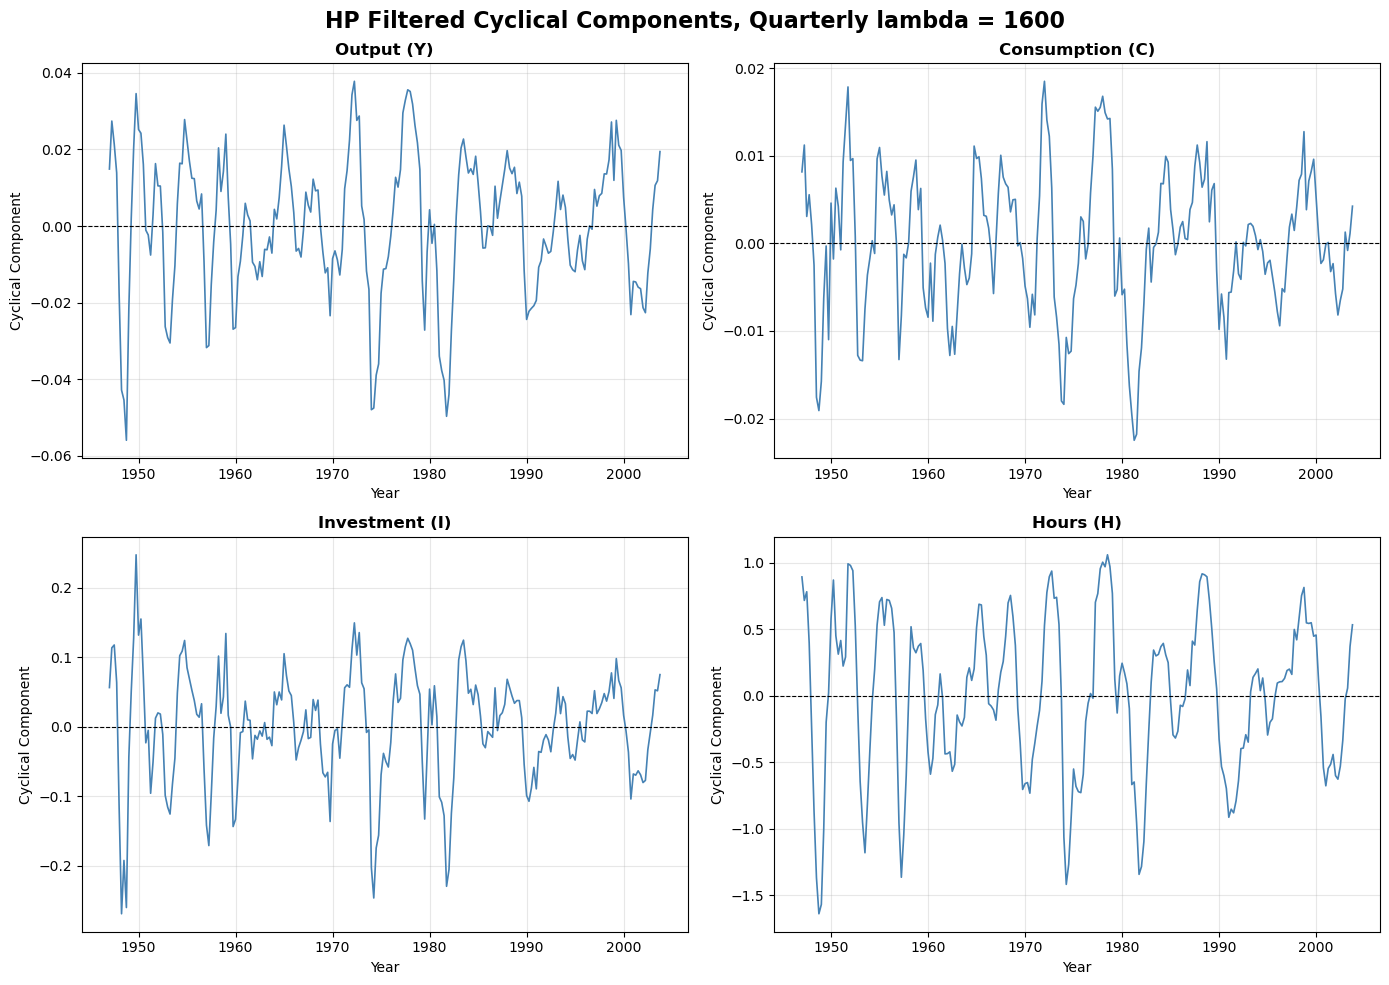

In [148]:
# Plot HP filtered ycih.
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('HP Filtered Cyclical Components, Quarterly lambda = 1600', 
                fontsize=16, fontweight='bold')

vars_list = ['Y', 'C', 'I', 'H']
titles = ['Output (Y)', 'Consumption (C)', 'Investment (I)', 'Hours (H)']

# Plot all 4 of the columns.
for idx, (var, title) in enumerate(zip(vars_list, titles)):
    ax = axes[idx // 2, idx % 2]
    ax.plot(
        df_ycih.index,
        df_ycih[f'{var}_cycle'],
        linewidth=1.2, color='steelblue'
    )
    ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('Cyclical Component')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Question 4.2 - ycih statistics after HP filtering.

In [149]:
# Compute statistics as in 'multivariate2026.pdf' slides 16-17.
# Table to fill in is given in the question.
stats_q4 = pd.DataFrame(
    index=['Y', 'C', 'I', 'H'],
    columns=['St Dev', 'First Autocorr', 'Corr with Y(t)',
            'Cross corr with Y(t-1)', 'Cross corr with Y(t+1)']
)

y_cycle = df_ycih['Y_cycle'].values

for var in ['Y', 'C', 'I', 'H']:
    var_cycle = df_ycih[f'{var}_cycle'].values
    
    # Standard deviation.
    stats_q4.loc[var, 'St Dev'] = var_cycle.std()
    
    # First autocorrelation using statsmodels. Chapter 1, page 12
    var_acf = acf(var_cycle, nlags=1, fft=False)
    stats_q4.loc[var, 'First Autocorr'] = var_acf[1]
    
    # Correlation with Y.
    stats_q4.loc[var, 'Corr with Y(t)'] = np.corrcoef(var_cycle, y_cycle)[0, 1]
    
    # Cross correlations. multivariate2026.pdf, slide 16
    # var(t) with Y(t-1) gives us the correlation between current variable and past output.
    stats_q4.loc[var, 'Cross corr with Y(t-1)'] = np.corrcoef(
        var_cycle[1:], y_cycle[:-1]
    )[0, 1]
    
    # var(t) with Y(t+1) gives us correlation between current variable and future output
    stats_q4.loc[var, 'Cross corr with Y(t+1)'] = np.corrcoef(
        var_cycle[:-1], y_cycle[1:]
    )[0, 1]

stats_q4 = stats_q4.astype(float)

stats_q4 = stats_q4.T.reset_index(names=['Statistic'])

display(stats_q4)

,Statistic,Y,C,I,H
0,St Dev,0.018122,0.008016,0.079647,0.589062
1,First Autocorr,0.851358,0.823799,0.782305,0.888588
2,Corr with Y(t),1.000000,0.808517,0.951513,0.828957
3,Cross corr with Y(t-1),0.854774,0.737408,0.787114,0.880452
4,Cross corr with Y(t+1),0.854774,0.725638,0.792450,0.607978


#### Per chapter 1 page 23, we may interpret the standard deviation as volitility. St Dev column I divided by St Dev column Y gives us 0.0796 / 0.0181 = 4.24, which is what we expect from page 23. "In turn, the standard deviation of investment is more than four times the standard deviation of output or, in the jargon of macroeconomists, investment is about four times more volatile than output."